In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load Week 1's cleaned dataset
df = pd.read_csv('../Week1/telco_churn_cleaned.csv')

# Recreate Week 2 engineered features
def tenure_group(t):
    if t <= 12: return '0-1 year'
    elif t <= 24: return '1-2 years'
    elif t <= 48: return '2-4 years'
    else: return '4+ years'

df['TenureGroup'] = df['tenure'].apply(tenure_group)

service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['NumServices'] = df[service_cols].apply(lambda row: sum(row == 'Yes'), axis=1)

df['SpendingTier'] = pd.qcut(df['MonthlyCharges'], q=3, labels=['Low', 'Medium', 'High'])

# Preprocessing
df_model = df.drop(columns=['customerID'])
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})
df_model = pd.get_dummies(df_model, drop_first=True)

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'NumServices']
scaler = StandardScaler()
df_model[num_cols] = scaler.fit_transform(df_model[num_cols])

print(df_model.shape)

# Save it properly this time, and confirm
df_model.to_csv('telco_churn_feature_engineered.csv', index=False)
print(os.listdir('.'))

(7043, 37)
['telco_churn_feature_engineered.csv', 'week3_model_development.ipynb']


In [7]:
df_model.to_csv('../Week2/telco_churn_feature_engineered.csv', index=False)

In [8]:
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(5634, 36) (1409, 36)


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                               f1_score, confusion_matrix, roc_auc_score, classification_report)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7998580553584103
Precision: 0.6554054054054054
Recall: 0.5187165775401069
F1-score: 0.5791044776119403
ROC-AUC: 0.8425327443230256

Confusion Matrix:
 [[933 102]
 [180 194]]


In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

for name, y_pred, y_proba in [('Decision Tree', y_pred_dt, y_proba_dt), ('Random Forest', y_pred_rf, y_proba_rf)]:
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1-score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print()

--- Decision Tree ---
Accuracy: 0.7423704755145494
Precision: 0.5154929577464789
Recall: 0.4893048128342246
F1-score: 0.5020576131687243
ROC-AUC: 0.6610671936758893
Confusion Matrix:
 [[863 172]
 [191 183]]

--- Random Forest ---
Accuracy: 0.7856635911994322
Precision: 0.6216216216216216
Recall: 0.4919786096256685
F1-score: 0.5492537313432836
ROC-AUC: 0.8218902580795164
Confusion Matrix:
 [[923 112]
 [190 184]]



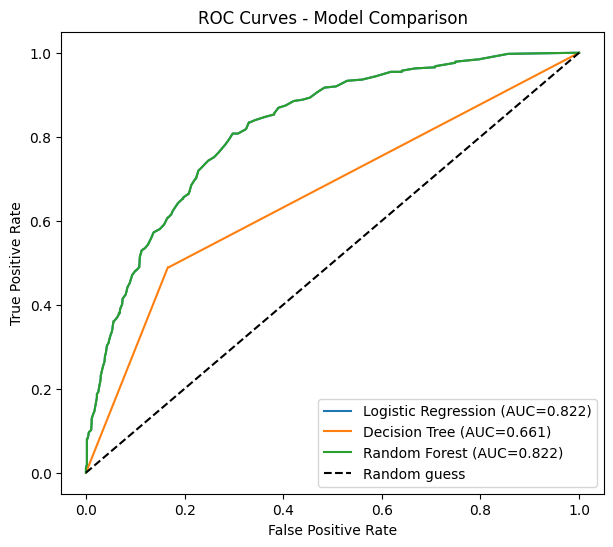

In [14]:
plt.figure(figsize=(7,6))
for name, proba_arr in [('Logistic Regression', y_proba), ('Decision Tree', y_proba_dt), ('Random Forest', y_proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, proba_arr)
    auc = roc_auc_score(y_test, proba_arr)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1], [0,1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend()
plt.show()

In [15]:
import joblib

joblib.dump(log_reg, 'logistic_regression_model.pkl')
joblib.dump(dt, 'decision_tree_model.pkl')
joblib.dump(rf, 'random_forest_model.pkl')

X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print("saved")

saved
